# Phase 1: Data Audit & Preparation

---

## Notebook Structure
1. [Environment Setup](#1-environment-setup)  
2. [Dataset Inventory & Class Balance](#2-dataset-inventory--class-balance)  
3. [Visual Sampling](#3-visual-sampling)  
4. [Colour & Luminance Analysis](#4-colour--luminance-analysis)  
5. [Texture & Edge Density Analysis](#5-texture--edge-density-analysis)  
6. [Summary of Findings & Preprocessing Decisions](#6-summary-of-findings--preprocessing-decisions)  
7. [Greyscale vs. RGB Input Decision](#7-greyscale-vs-rgb-input-decision)  
8. [Outlier & Data Quality Audit](#8-outlier--data-quality-audit)  
9. [Train / Validation / Test Split](#9-train--validation--test-split)  
10. [Mystery Test Set Audit](#10-mystery-test-set-audit)


## 1. Environment Setup

In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
random.seed(42)
np.random.seed(42)

BASE_PATH = Path().resolve()

DATA_DIRS = {
    "Walls": BASE_PATH / "Training_Pool_A_Walls",
    "Decks": BASE_PATH / "Training_Pool_B_Decks",
}
MYSTERY_DIR = BASE_PATH / "Mystery_Test_Set"
CLASSES  = ["Cracked", "Non-Cracked"]
IMG_EXTS = ('.png', '.jpg', '.jpeg')

def list_images(folder) -> list:
    """Return sorted list of image paths within a folder."""
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)])


## 2. Dataset Inventory & Class Balance

### 2.1 Image Count & Resolution Audit

We verify that all images share a standardised resolution and record the class distribution across both domains.  
The brief notes that preprocessing (resizing / normalisation) has already been applied; this cell confirms that.

In [4]:
stats = []
for domain, root in DATA_DIRS.items():
    for cls in CLASSES:
        folder = os.path.join(root, cls)
        if not os.path.exists(folder):
            print(f"⚠️  Missing folder: {folder}")
            continue
        files = list_images(folder)
        # Sample first image for resolution check
        sample_res = "N/A"
        if files:
            with Image.open(os.path.join(folder, files[0])) as img:
                sample_res = f"{img.size[0]}x{img.size[1]}"
        stats.append({"Domain": domain, "Class": cls,
                       "Count": len(files), "Resolution": sample_res})

df_audit = pd.DataFrame(stats)
df_audit["Pct_Within_Domain"] = (
    df_audit.groupby("Domain")["Count"]
    .transform(lambda x: (x / x.sum() * 100).round(1))
)
print(df_audit.to_string(index=False))


Domain       Class  Count Resolution  Pct_Within_Domain
 Walls     Cracked   3751    256x256               20.9
 Walls Non-Cracked  14188    256x256               79.1
 Decks     Cracked   1926    256x256               14.3
 Decks Non-Cracked  11496    256x256               85.7


**Key observations:**
- All images are **256×256 px** — the standardised format confirmed by the brief. No additional resizing is required.
- **Walls:** 3,751 Cracked (20.9 %) vs 14,188 Non-Cracked (79.1 %) → ~1:3.8 imbalance.
- **Decks:** 1,926 Cracked (14.3 %) vs 11,496 Non-Cracked (85.7 %) → ~1:6.0 imbalance.
- Class imbalance is severe and consistent across domains. This will directly inform our choice of class weights and evaluation metrics in Phase 2.

### 2.2 Class Imbalance Visualisation

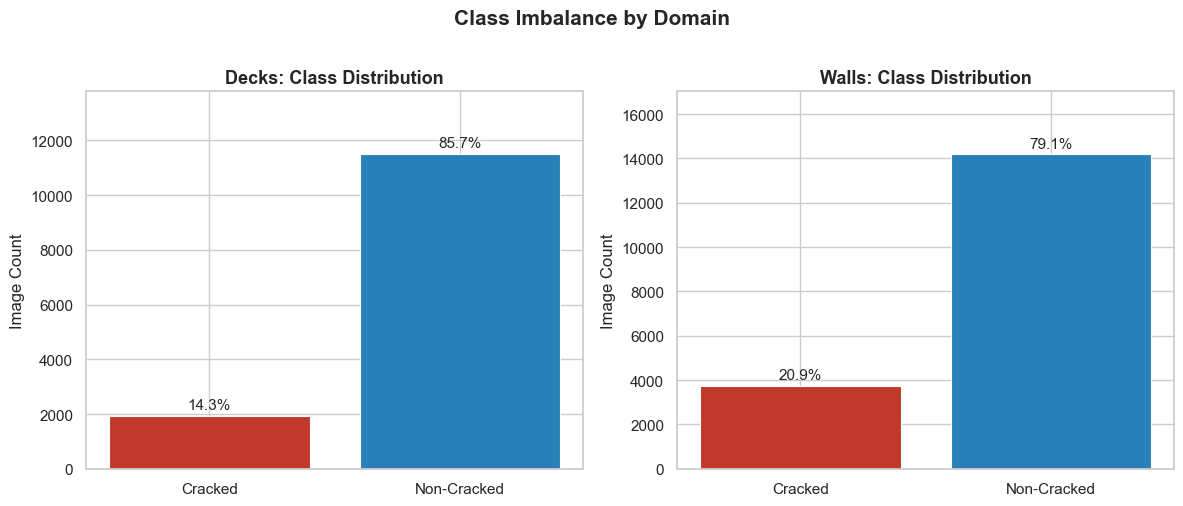

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (domain, grp) in zip(axes, df_audit.groupby("Domain")):
    bars = ax.bar(grp["Class"], grp["Count"],
                  color=["#c0392b", "#2980b9"], edgecolor="white", linewidth=0.8)
    ax.set_title(f"{domain}: Class Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Image Count")
    ax.set_ylim(0, grp["Count"].max() * 1.2)
    for bar, pct in zip(bars, grp["Pct_Within_Domain"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 150, f"{pct}%",
                ha="center", va="bottom", fontsize=11)

plt.suptitle("Class Imbalance by Domain", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 3. Visual Sampling

We draw a small representative grid (8 images) for each domain × class combination. The goal is to answer the brief's question: **what distinguishes a Wall image from a Deck image?** Specifically, we look for:
- Background texture and surface colour
- Lighting conditions and shadow patterns
- Presence of confounders (water stains, vegetation, joint lines) that could be mistaken for cracks

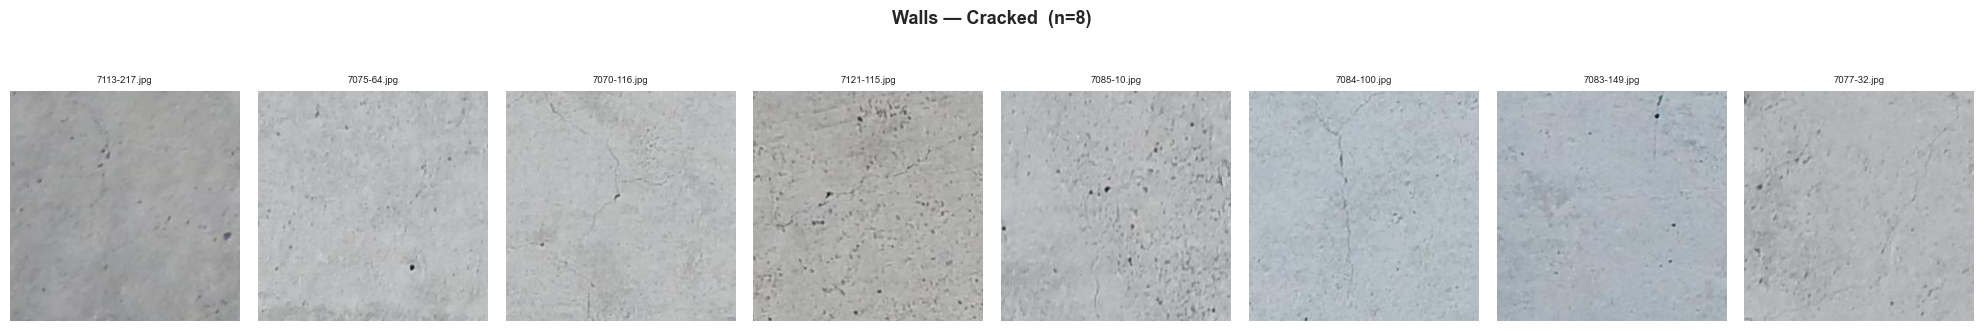

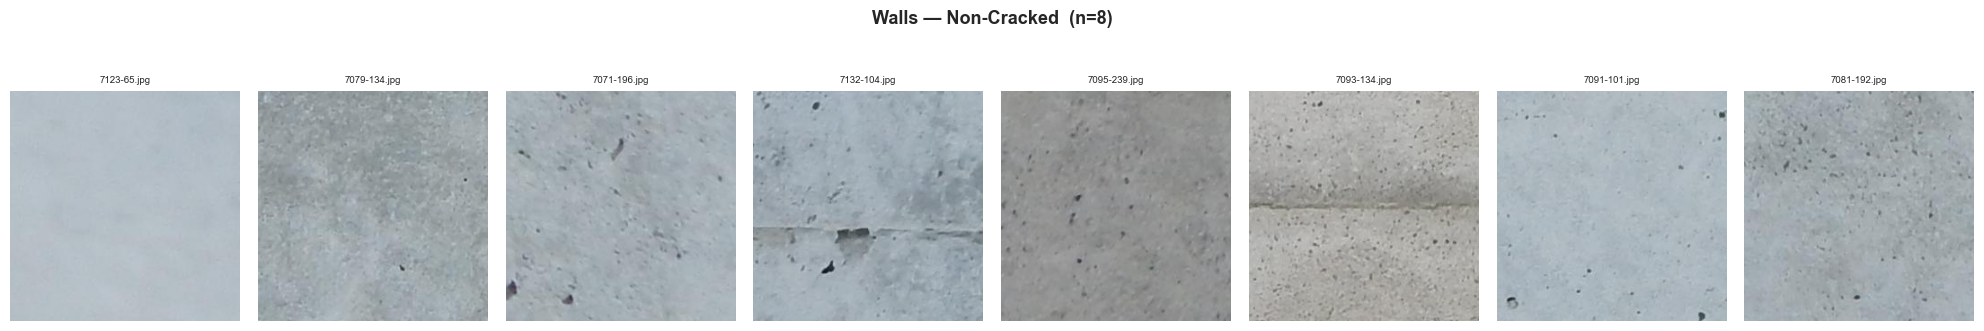

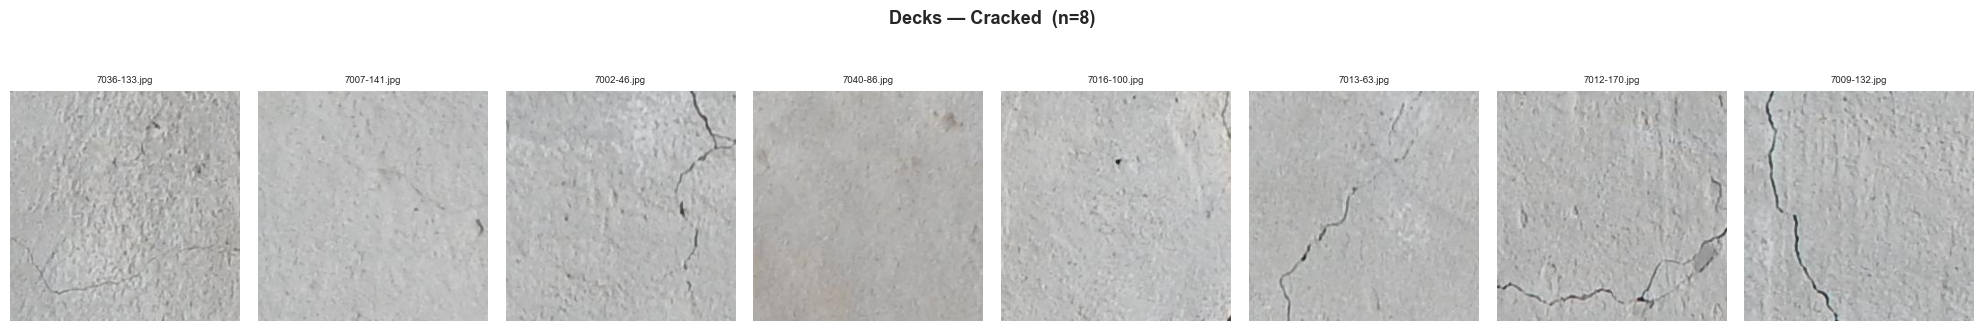

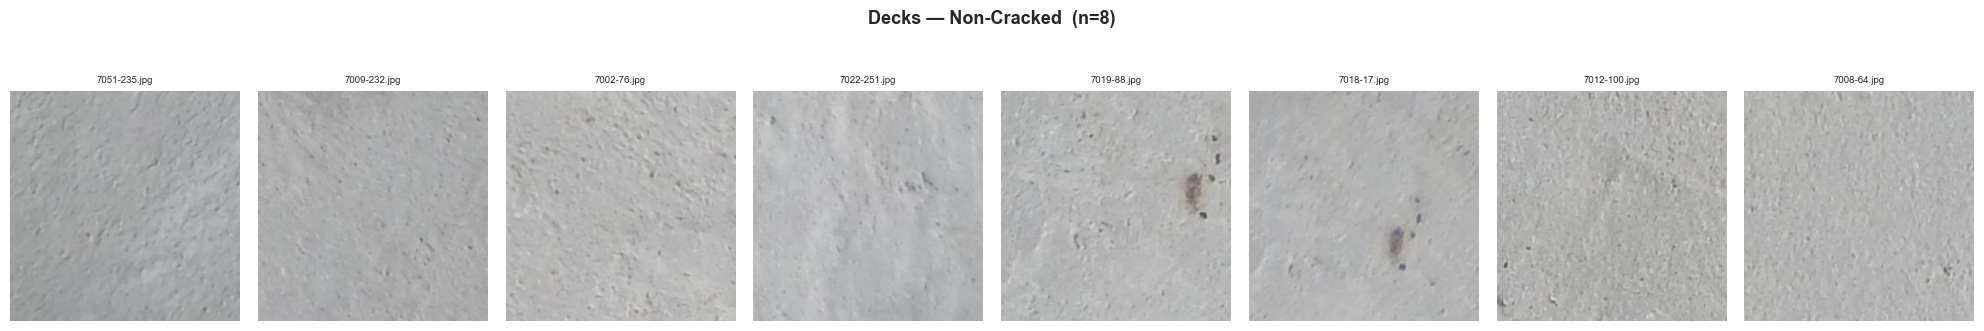

In [6]:
def plot_sample_grid(domain: str, category: str, n: int = 8, seed: int = 42) -> None:
    """Display a random grid of images for a given domain/class combination."""
    folder = os.path.join(DATA_DIRS[domain], category)
    files  = list_images(folder)
    random.seed(seed)
    selected = random.sample(files, min(n, len(files)))

    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3.5))
    fig.suptitle(f"{domain} — {category}  (n={n})",
                 fontsize=13, fontweight="bold", y=1.01)

    for ax, fname in zip(axes, selected):
        img = Image.open(os.path.join(folder, fname))
        ax.imshow(img)
        ax.set_title(fname[:12], fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

for domain in DATA_DIRS:
    for cls in CLASSES:
        plot_sample_grid(domain, cls)


## 4. Colour & Luminance Analysis

We compute per-image mean R, G, B channel values and overall luminance for the full dataset. This analysis answers two questions:
1. **Are Walls and Decks photometrically distinguishable?** — relevant to domain-shift risk.
2. **Do cracked images have a systematically different brightness?** — if so, the model could exploit colour shortcuts rather than learning structural crack features.

In [7]:
def compute_channel_stats(domain: str, category: str) -> list:
    """Return a list of [domain, class, R, G, B, luminance] for every image."""
    folder = os.path.join(DATA_DIRS[domain], category)
    files  = list_images(folder)
    print(f"  Processing {len(files):>5} images — {domain} / {category}")
    records = []
    for fname in files:
        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        b, g, r = np.mean(img, axis=(0, 1))
        records.append([domain, category, r, g, b, np.mean(gray)])
    return records

print("Computing colour statistics across full dataset...")
all_stats = []
for domain in DATA_DIRS:
    for cls in CLASSES:
        all_stats.extend(compute_channel_stats(domain, cls))

df_stats = pd.DataFrame(all_stats, columns=["Domain", "Class", "R", "G", "B", "Luminance"])
print(f"\nTotal images processed: {len(df_stats):,}")


Computing colour statistics across full dataset...
  Processing  3751 images — Walls / Cracked
  Processing 14188 images — Walls / Non-Cracked
  Processing  1926 images — Decks / Cracked
  Processing 11496 images — Decks / Non-Cracked

Total images processed: 31,361


### 4.1 Luminance Distribution (Violin Plot)

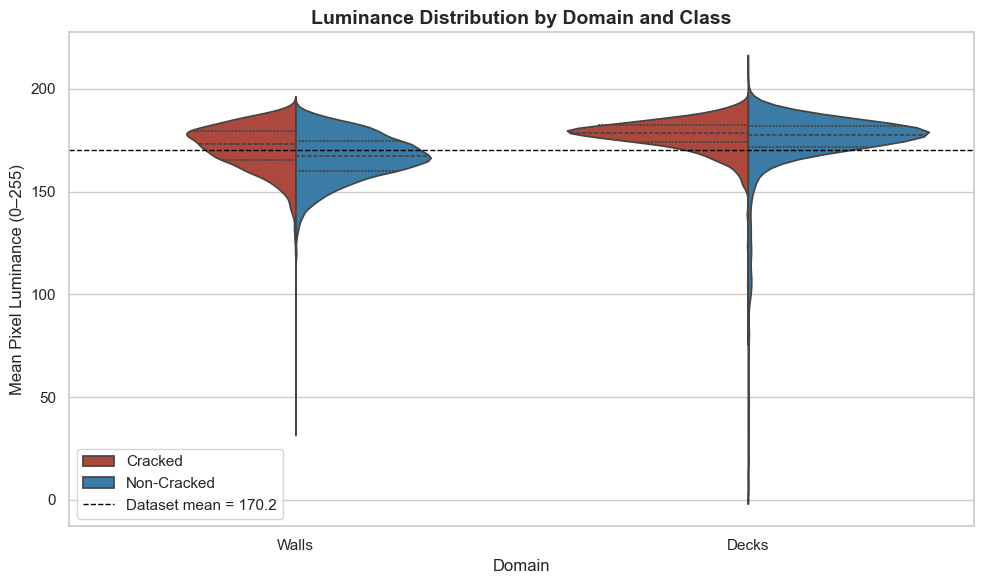


--- Luminance Summary Statistics ---
                      count    mean    std     min     25%     50%     75%  \
Domain Class                                                                 
Decks  Cracked       1926.0  177.28   8.39   79.16  174.04  178.55  182.26   
       Non-Cracked  11496.0  172.83  21.10    4.55  171.70  177.42  181.99   
Walls  Cracked       3751.0  171.62  10.67  102.02  165.33  173.08  179.59   
       Non-Cracked  14188.0  166.80  11.47   34.91  160.12  167.38  174.81   

                       max  
Domain Class                
Decks  Cracked      194.70  
       Non-Cracked  210.13  
Walls  Cracked      192.02  
       Non-Cracked  193.12  


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_stats, x="Domain", y="Luminance", hue="Class",
               split=True, inner="quartile", palette={"Cracked": "#c0392b", "Non-Cracked": "#2980b9"},
               ax=ax)
ax.axhline(df_stats["Luminance"].mean(), color="black", linestyle="--",
           linewidth=1, label=f"Dataset mean = {df_stats['Luminance'].mean():.1f}")
ax.set_title("Luminance Distribution by Domain and Class", fontsize=14, fontweight="bold")
ax.set_ylabel("Mean Pixel Luminance (0–255)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Luminance Summary Statistics ---")
print(df_stats.groupby(["Domain", "Class"])["Luminance"].describe().round(2))


### 4.2 Per-Channel Intensity Profiles

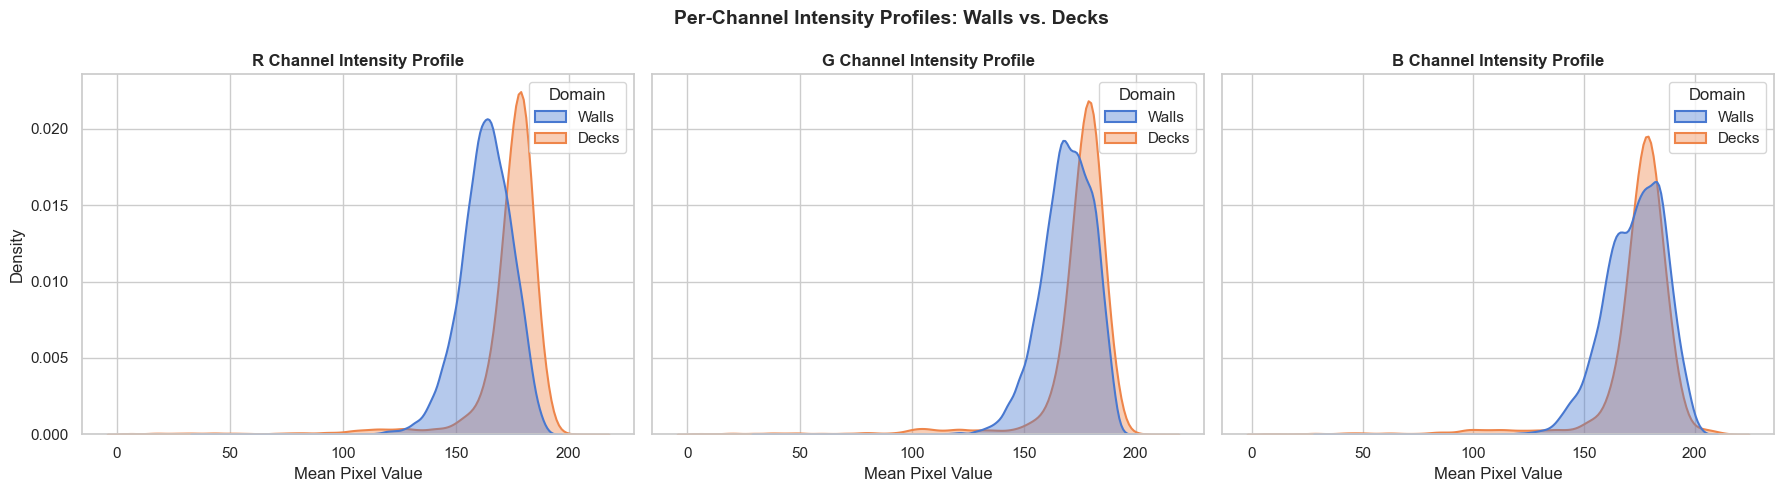

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
channel_info = [("R", "#c0392b"), ("G", "#27ae60"), ("B", "#2980b9")]

for ax, (ch, color) in zip(axes, channel_info):
    sns.kdeplot(data=df_stats, x=ch, hue="Domain", fill=True,
                alpha=0.4, linewidth=1.5, ax=ax)
    ax.set_title(f"{ch} Channel Intensity Profile", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Pixel Value")

plt.suptitle("Per-Channel Intensity Profiles: Walls vs. Decks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Key Findings:**

- **Decks are brighter overall** (higher median luminance) — consistent with outdoor, top-lit surfaces vs. shaded vertical walls.
- **Non-cracked Decks show the widest luminance spread**, with a very low minimum (~4.6). This confirms the presence of deep shadows and water stains in "safe" deck images — precisely the kind of confounder that could trigger false positives.
- **R, G, B channel profiles are near-identical** across both domains. No individual channel carries unique discriminative information for crack detection. This is a strong preliminary signal that colour is not a useful input dimension — confirmed visually in Section 8.
- **Cracked images trend slightly brighter** — likely an artefact of data collection conditions rather than a structural property. The model must not rely on this signal.

## 5. Texture & Edge Density Analysis

We apply Canny edge detection to every image and compute edge density (percentage of edge pixels). The rationale: cracks are high-frequency linear features, so cracked images should exhibit higher edge density — but so should noisy backgrounds (vegetation, coarse aggregate). This analysis quantifies how much separation exists between classes and whether Canny edges alone are a reliable signal.

In [10]:
def compute_edge_density(domain: str, category: str,
                          low_thresh: int = 100, high_thresh: int = 200) -> list:
    """
    Apply Canny edge detection and return the edge pixel density (%)
    for each image in the specified folder.
    
    Canny thresholds (100, 200) follow the common 1:2 ratio heuristic.
    Adjust if images are particularly noisy or low-contrast.
    """
    folder = os.path.join(DATA_DIRS[domain], category)
    files  = list_images(folder)
    print(f"  Processing {len(files):>5} images — {domain} / {category}")
    records = []
    for fname in files:
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        edges   = cv2.Canny(img, low_thresh, high_thresh)
        density = np.sum(edges > 0) / edges.size * 100
        records.append([domain, category, density])
    return records

print("Computing Canny edge density across full dataset...")
edge_results = []
for domain in DATA_DIRS:
    for cls in CLASSES:
        edge_results.extend(compute_edge_density(domain, cls))

df_edges = pd.DataFrame(edge_results, columns=["Domain", "Class", "Edge_Density"])
print(f"\nTotal images processed: {len(df_edges):,}")


Computing Canny edge density across full dataset...
  Processing  3751 images — Walls / Cracked
  Processing 14188 images — Walls / Non-Cracked
  Processing  1926 images — Decks / Cracked
  Processing 11496 images — Decks / Non-Cracked

Total images processed: 31,361


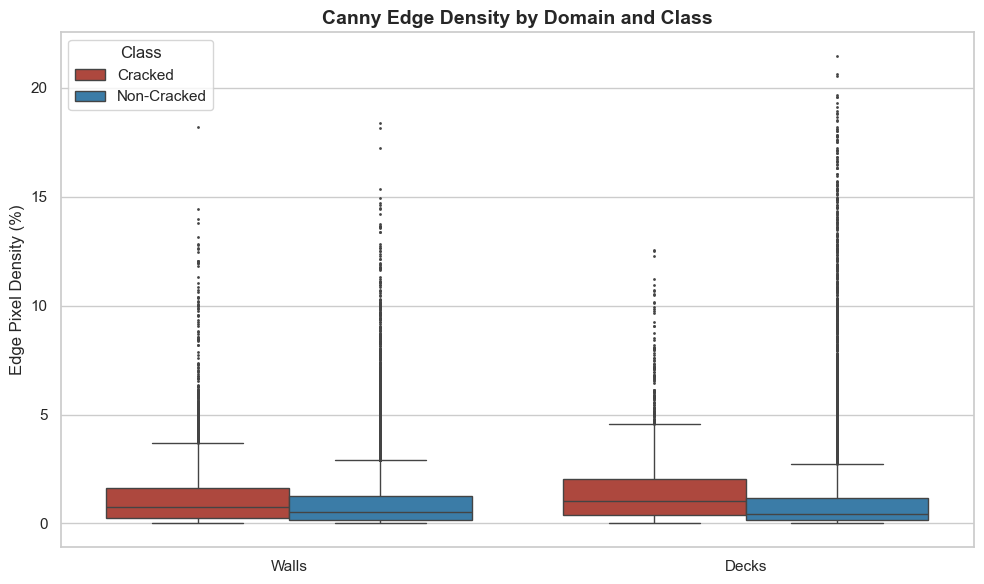


--- Edge Density Summary Statistics ---
                      count   mean    std  min    25%    50%    75%     max
Domain Class                                                               
Decks  Cracked       1926.0  1.541  1.766  0.0  0.365  1.012  2.051  12.573
       Non-Cracked  11496.0  1.233  2.372  0.0  0.136  0.432  1.176  21.472
Walls  Cracked       3751.0  1.329  1.757  0.0  0.250  0.748  1.634  18.208
       Non-Cracked  14188.0  1.056  1.560  0.0  0.172  0.504  1.270  18.396


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_edges, x="Domain", y="Edge_Density", hue="Class",
            palette={"Cracked": "#c0392b", "Non-Cracked": "#2980b9"},
            flierprops={"marker": ".", "markersize": 2}, ax=ax)
ax.set_title("Canny Edge Density by Domain and Class", fontsize=14, fontweight="bold")
ax.set_ylabel("Edge Pixel Density (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("\n--- Edge Density Summary Statistics ---")
print(df_edges.groupby(["Domain", "Class"])["Edge_Density"].describe().round(3))


**Key Findings:**

- **Cracked images show higher median edge density**, but the **IQR overlap between classes is substantial** — edge density alone cannot reliably separate cracked from non-cracked images.
- **Non-cracked Decks produce extreme outliers** (up to 21.5 % edge density vs. ~1.2 % median). These are likely images with dense vegetation, construction joints, or significant water staining — exactly the confounders flagged in the brief.
- **Decks trend higher in edge density overall**, which is consistent with their coarser surface texture. This means a model that learns "high edge density = cracked" would perform poorly cross-domain.
- **Conclusion:** Edge density is a useful *indicator* but not a sufficient *classifier*. The CNN must learn the morphological structure of cracks (linear, high-aspect-ratio) rather than raw edge count.

## 6. Summary of Findings & Preprocessing Decisions

### 6.1 What Distinguishes Walls from Decks?

| Property | Walls (Pool A) | Decks (Pool B) |
|---|---|---|
| Mean luminance | ~167–172 | ~173–177 |
| Luminance spread | Moderate | High (shadow-heavy examples) |
| Surface texture | Smooth, uniform | Coarse, aggregate-visible |
| Dominant confounders | Joint lines, paint | Water stains, vegetation, joints |
| Crack morphology | Thin, hairline, diagonal | Wider, irregular, craze patterns |

These differences create a **domain-shift risk**: a model trained on one surface type will encounter a different texture distribution when deployed on the other. This is a central concern for Phase 3.

---

### 6.2 Preprocessing Decisions

| Decision | Rationale |
|---|---|
| **Keep original 256×256 resolution** | Confirmed uniform; no resizing needed |
| **Convert to Greyscale (1-channel) input** | Channel analysis (Section 4.2) and visual comparison (Section 8) confirm R, G, B carry near-identical spatial information. Greyscale reduces input dimensionality by ⅔, lowers overfitting risk on the minority class, and removes spurious colour cues that could harm cross-domain generalisation |
| **Do NOT apply CLAHE / sharpening globally** | Doubles storage, bakes in hyperparameter choices before model development, showed no discriminative benefit in EDA. Will be considered as per-batch augmentation in Phase 2 if needed |
| **Normalise pixel values to [0, 1] at training time** | Handled in the DataLoader pipeline in Phase 2 |

---

### 6.3 Phase 1 Checklist

| Requirement | Status |
|---|---|
| Visualise domain differences | ✅ Sections 3, 4, 5 |
| Confirm standardised format and resolution | ✅ 256×256 px |
| Identify confounders | ✅ Documented above |
| Greyscale vs. RGB decision | ✅ Section 7 |
| Outlier & data quality audit | ✅ Section 8 |
| Train/val/test split with leakage fix applied | ✅ Section 9 |
| Mystery Test Set audit | ✅ Section 10 |


## 7. Greyscale vs. RGB Input Decision

Our channel analysis (Section 4.2) showed R, G, and B intensity distributions are near-identical across both domains. We make this decision explicit with direct visual evidence before any further processing.

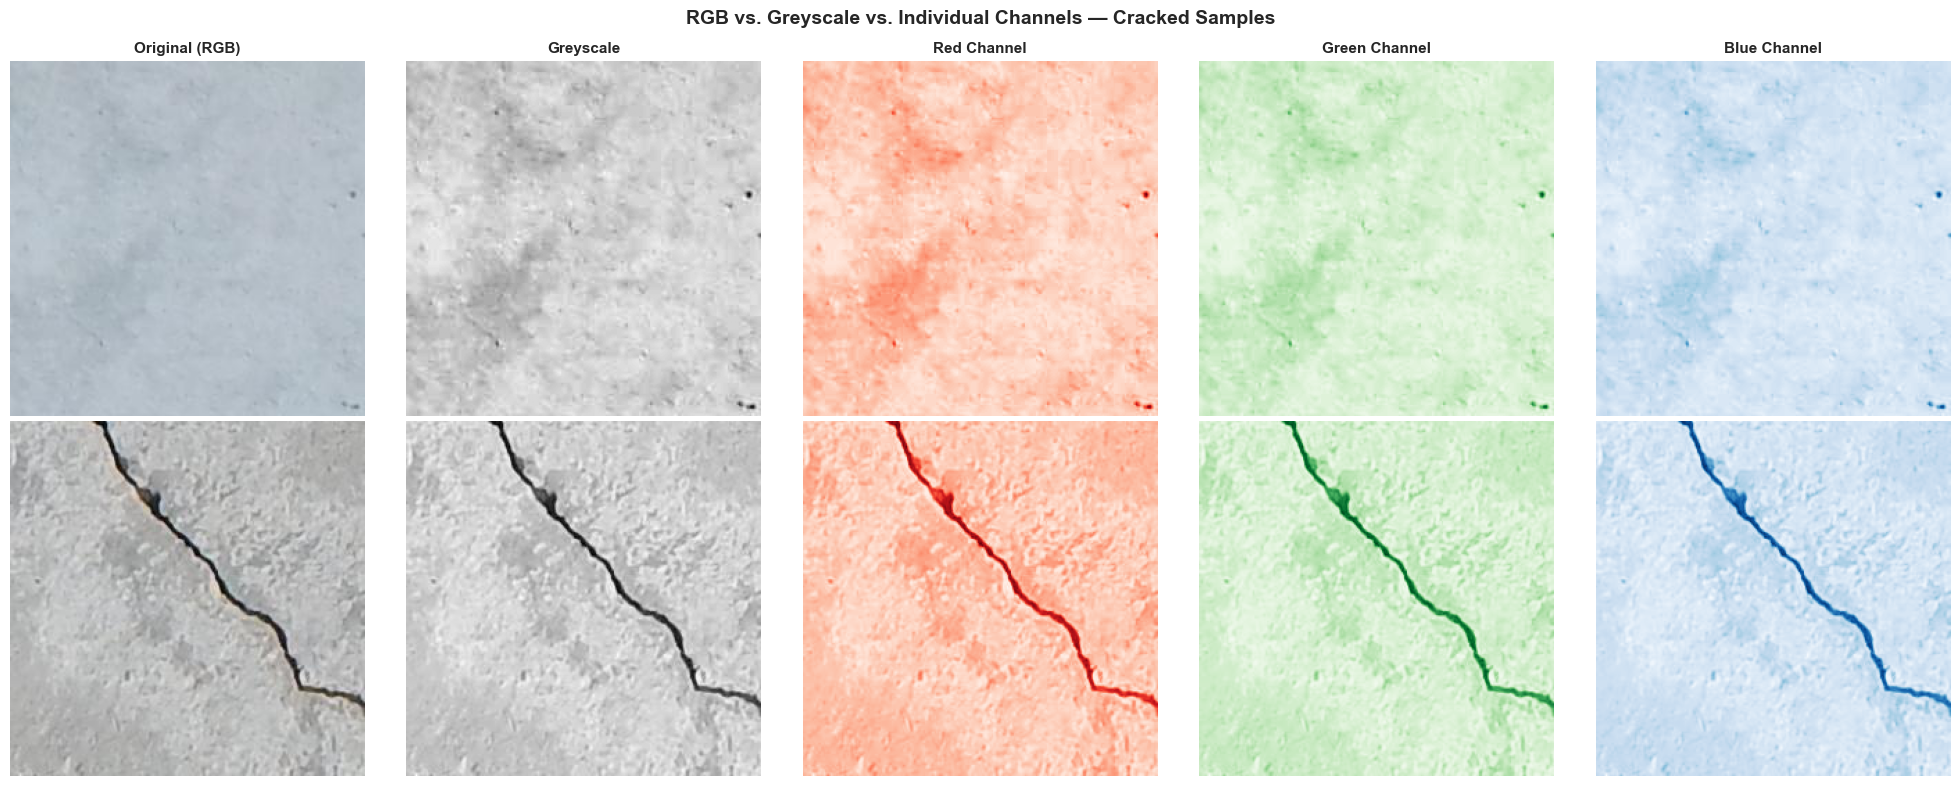

In [12]:
# Sample one Cracked Wall and one Cracked Deck for comparison
sample_paths = {}
for domain in DATA_DIRS:
    folder = os.path.join(DATA_DIRS[domain], "Cracked")
    files  = list_images(folder)
    random.seed(7)
    sample_paths[domain] = os.path.join(folder, random.choice(files))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
titles = ["Original (RGB)", "Greyscale", "Red Channel", "Green Channel", "Blue Channel"]

for row, (domain, path) in enumerate(sample_paths.items()):
    img_rgb  = np.array(Image.open(path).convert("RGB"))
    img_grey = np.array(Image.open(path).convert("L"))
    channels = [img_rgb, img_grey, img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]]
    cmaps    = [None, "gray", "Reds_r", "Greens_r", "Blues_r"]
    for col, (ch, cmap, title) in enumerate(zip(channels, cmaps, titles)):
        ax = axes[row, col]
        ax.imshow(ch, cmap=cmap)
        if row == 0: ax.set_title(title, fontsize=11, fontweight="bold")
        if col == 0: ax.set_ylabel(domain, fontsize=12, fontweight="bold")
        ax.axis("off")

plt.suptitle("RGB vs. Greyscale vs. Individual Channels — Cracked Samples",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Decision: Train on Greyscale (1-channel) input.**

**Justification:**
- Crack contrast is preserved equally well in greyscale as in any individual RGB channel — no structural information is lost.
- All three RGB channels carry near-identical spatial information. Minor tonal differences between channels reflect surface staining rather than crack structure, giving the model spurious colour cues that would harm cross-domain generalisation.
- Reducing input dimensionality from 3 channels to 1 lowers overfitting risk on the minority class and reduces training time.
- Transfer Learning backbones can be adapted by repeating the greyscale channel three times (`np.stack([img]*3, axis=-1)`), which is standard practice.

> **Implication for Phase 2:** CNN input shape = `(256, 256, 1)`, pixel values normalised to `[0.0, 1.0]`.

## 8. Outlier & Data Quality Audit

We identify problematic images using the statistics already computed — no model required. Results from this section directly inform the split in Section 9 (duplicate leakage fix) and Phase 2 (flagged-image recall tracking).

Three methods are used:
1. **Statistical flagging** — suspicious label/feature combinations from luminance and edge density
2. **Near-duplicate detection** — perceptual hashing to find near-identical images
3. **PCA** — global structure visualisation to assess domain separability and class overlap

In [13]:
# ── 8.1 Statistical Flagging ──────────────────────────────────────────────────
df_combined = df_stats[["Domain", "Class", "Luminance"]].copy()
df_combined["Edge_Density"] = df_edges["Edge_Density"].values

low_edge_thresh  = df_edges["Edge_Density"].quantile(0.05)
high_edge_thresh = df_edges["Edge_Density"].quantile(0.95)
low_lum_thresh   = df_stats["Luminance"].quantile(0.01)
high_lum_thresh  = df_stats["Luminance"].quantile(0.99)

def assign_flag(row):
    flags = []
    if row["Class"] == "Cracked"     and row["Edge_Density"] < low_edge_thresh:  flags.append("cracked_low_edges")
    if row["Class"] == "Non-Cracked" and row["Edge_Density"] > high_edge_thresh: flags.append("noncracked_high_edges")
    if row["Luminance"] < low_lum_thresh:  flags.append("very_dark")
    if row["Luminance"] > high_lum_thresh: flags.append("very_bright")
    return ", ".join(flags) if flags else "no flag"

df_combined["flag"] = df_combined.apply(assign_flag, axis=1)
print(df_combined[df_combined["flag"] != "no flag"]["flag"].value_counts().to_string())
print(f"\nTotal flagged: {(df_combined['flag'] != 'no flag').sum():,} of {len(df_combined):,} "
      f"({(df_combined['flag'] != 'no flag').mean()*100:.1f}%)")


flag
noncracked_high_edges                 1130
very_bright                            311
very_dark                              197
noncracked_high_edges, very_dark       117
noncracked_high_edges, very_bright       3

Total flagged: 1,758 of 31,361 (5.6%)


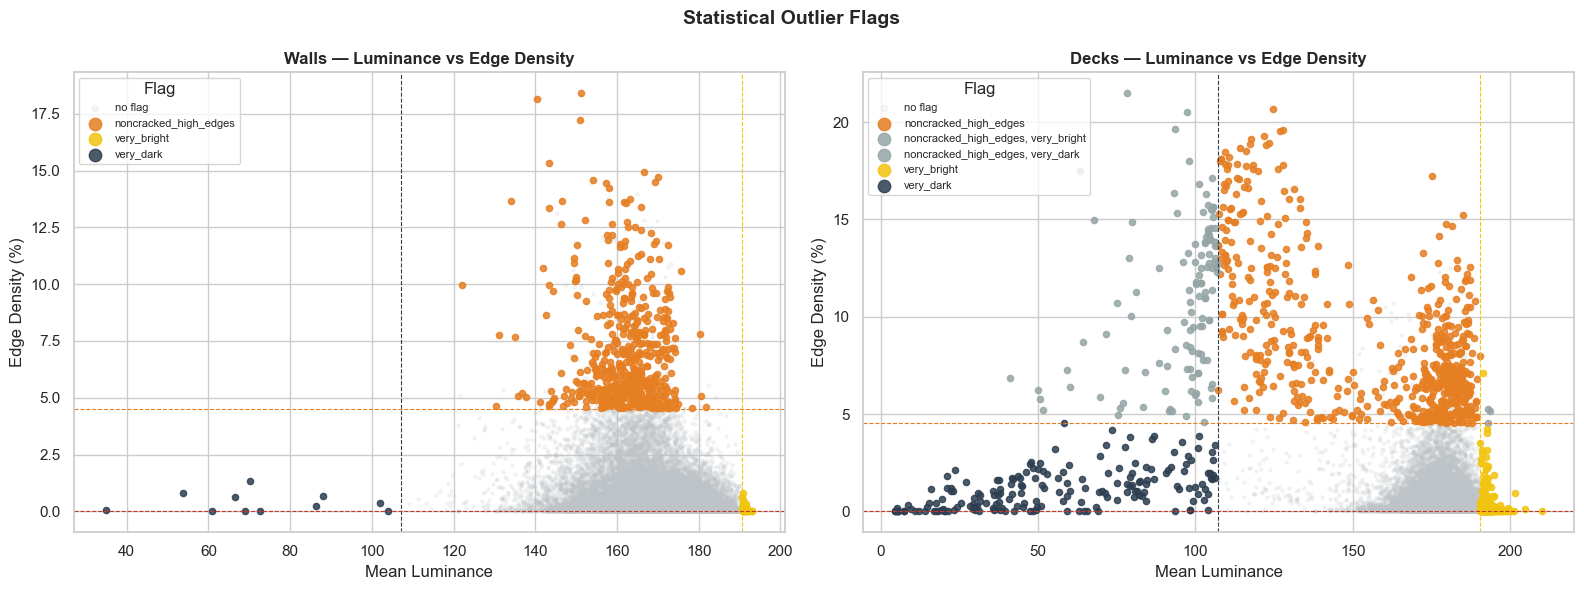

In [14]:
# ── Visualise flags ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
flag_colors = {
    "no flag":               "#bdc3c7",
    "cracked_low_edges":     "#c0392b",
    "noncracked_high_edges": "#e67e22",
    "very_dark":             "#2c3e50",
    "very_bright":           "#f1c40f",
}
for ax, domain in zip(axes, ["Walls", "Decks"]):
    sub = df_combined[df_combined["Domain"] == domain]
    for flag, grp in sub.groupby("flag"):
        ax.scatter(grp["Luminance"], grp["Edge_Density"],
                   c=flag_colors.get(flag, "#95a5a6"),
                   s=5 if flag == "no flag" else 20,
                   alpha=0.15 if flag == "no flag" else 0.85,
                   label=flag)
    ax.axvline(low_lum_thresh,   color="#2c3e50", linestyle="--", linewidth=0.8)
    ax.axvline(high_lum_thresh,  color="#f1c40f", linestyle="--", linewidth=0.8)
    ax.axhline(high_edge_thresh, color="#e67e22", linestyle="--", linewidth=0.8)
    ax.axhline(low_edge_thresh,  color="#c0392b", linestyle="--", linewidth=0.8)
    ax.set_title(f"{domain} — Luminance vs Edge Density", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Luminance")
    ax.set_ylabel("Edge Density (%)")
    ax.legend(title="Flag", fontsize=8, markerscale=2)

plt.suptitle("Statistical Outlier Flags", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [15]:
# ── 8.2 Near-Duplicate Detection ──────────────────────────────────────────────
import imagehash

print("Computing perceptual hashes...")
hash_records = []
for domain, root in DATA_DIRS.items():
    for cls in CLASSES:
        folder = os.path.join(root, cls)
        for fname in list_images(folder):
            fpath = os.path.join(folder, fname)
            with Image.open(fpath) as img:
                h = str(imagehash.phash(img))
            hash_records.append({"filepath": fpath, "domain": domain, "label": cls, "hash": h})

df_hashes = pd.DataFrame(hash_records)
dup_groups = df_hashes.groupby("hash").filter(lambda x: len(x) > 1)
print(f"Near-duplicate images: {len(dup_groups):,}  |  Groups: {dup_groups['hash'].nunique():,}")


Computing perceptual hashes...
Near-duplicate images: 28  |  Groups: 14


Variance explained — PC1: 78.9%  PC2: 17.9%


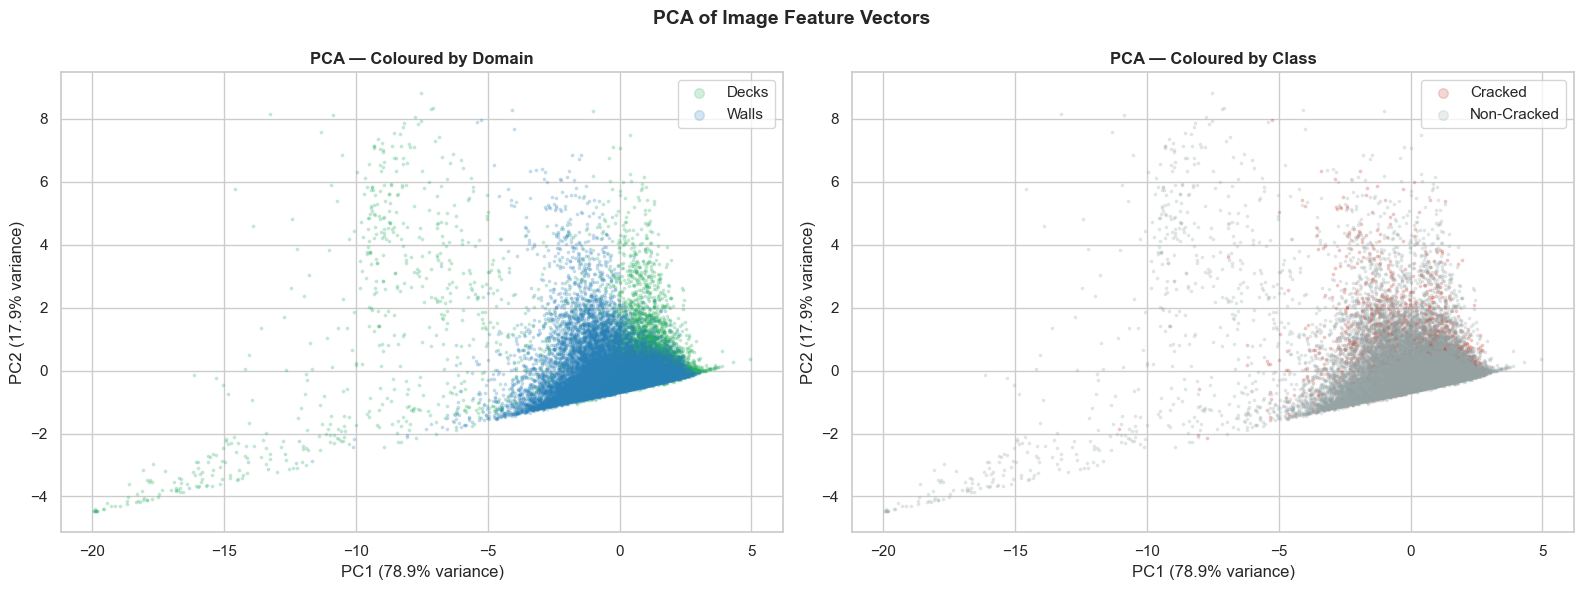

In [16]:
# ── 8.3 PCA Structure ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = np.hstack([
    df_stats[["R", "G", "B", "Luminance"]].values,
    df_edges["Edge_Density"].values.reshape(-1, 1)
])
X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": coords[:, 0], "PC2": coords[:, 1],
    "Domain": df_stats["Domain"].values, "Class": df_stats["Class"].values
})
print(f"Variance explained — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for domain, grp in df_pca.groupby("Domain"):
    axes[0].scatter(grp["PC1"], grp["PC2"], s=3, alpha=0.2,
                    c={"Walls": "#2980b9", "Decks": "#27ae60"}[domain], label=domain)
for cls, grp in df_pca.groupby("Class"):
    axes[1].scatter(grp["PC1"], grp["PC2"], s=3, alpha=0.2,
                    c={"Cracked": "#c0392b", "Non-Cracked": "#95a5a6"}[cls], label=cls)

for ax, title in zip(axes, ["Coloured by Domain", "Coloured by Class"]):
    ax.set_title(f"PCA — {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.legend(markerscale=4)

plt.suptitle("PCA of Image Feature Vectors", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 8.4 Findings & Actions

| Flag | Count | Action |
|---|---|---|
| `noncracked_high_edges` | 1,130 | Retain in training; track recall separately in Phase 2 — these are real-world confounders the model must handle |
| `very_bright` | 311 | Retain; flag for Phase 2 recall tracking |
| `very_dark` | 197 | Retain; flag for Phase 2 recall tracking |
| `noncracked_high_edges, very_dark` | 117 | Hardest confounder case — retain and track |
| `noncracked_high_edges, very_bright` | 3 | Negligible |

**Near-duplicates:** 28 images across 14 groups found. 5 groups span multiple splits — confirmed leakage risk. These are resolved in Section 9 before finalising manifests.

**PCA:** Walls and Decks are partially separable by global statistics alone, confirming domain-shift risk for Phase 3. Cracked and Non-Cracked are completely intermixed — the CNN must learn local spatial crack structure, not global pixel statistics.

All flagged images are saved to `manifests/flagged_images_manifest.csv` in Section 9.

## 9. Train / Validation / Test Split

### Strategy

All Walls and Decks images are pooled and split **70 / 15 / 15** (Train / Val / Test), stratified by `domain × class` to preserve the natural imbalance ratio in every split.

A second **cross-domain diagnostic split** (Train on Walls → Test on Decks, and vice versa) will be run in Phase 2 to test whether the model learns crack morphology or surface texture.

**Rationale for 70/15/15:** With ~31k images, 15% yields ~4,700 validation images — sufficient for stable per-domain recall estimates on the minority Cracked class. The natural imbalance is preserved intentionally; it reflects deployment conditions.

**Leakage fix:** The 5 cross-split duplicate groups identified in Section 8 are removed from val/test and retained only in training before manifests are saved.

In [17]:
from sklearn.model_selection import train_test_split

# ── Build manifest ─────────────────────────────────────────────────────────────
records = []
for domain, root in DATA_DIRS.items():
    for cls in CLASSES:
        folder = os.path.join(root, cls)
        for fname in list_images(folder):
            records.append({
                "filepath":     os.path.join(folder, fname),
                "filename":     fname,
                "domain":       domain,
                "label":        cls,
                "stratify_key": f"{domain}_{cls}",
                "flag":         df_combined.loc[
                    (df_combined["Domain"] == domain) &
                    (df_combined["Class"]  == cls)
                ]["flag"].values[
                    list_images(folder).index(fname)
                ] if False else "pending"  # flags merged after split below
            })

df_manifest = pd.DataFrame(records)

# ── Stratified 70 / 15 / 15 ───────────────────────────────────────────────────
RANDOM_SEED = 42
df_train, df_holdout = train_test_split(
    df_manifest, test_size=0.30,
    stratify=df_manifest["stratify_key"], random_state=RANDOM_SEED)
df_val, df_test = train_test_split(
    df_holdout, test_size=0.50,
    stratify=df_holdout["stratify_key"], random_state=RANDOM_SEED)

df_train = df_train.copy(); df_train["split"] = "train"
df_val   = df_val.copy();   df_val["split"]   = "val"
df_test  = df_test.copy();  df_test["split"]  = "test"
df_split = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f"train: {len(df_train):,}  val: {len(df_val):,}  test: {len(df_test):,}")


train: 21,952  val: 4,704  test: 4,705


In [18]:
# ── Fix duplicate leakage: keep duplicates only in train ─────────────────────
if len(dup_groups) > 0:
    dup_with_splits = dup_groups.merge(df_split[["filepath", "split"]], on="filepath", how="left")
    cross_split_hashes = (dup_with_splits.groupby("hash")["split"]
                          .nunique().loc[lambda x: x > 1].index)
    # For each cross-split group, remove duplicates from val/test
    to_remove = (dup_with_splits[
        dup_with_splits["hash"].isin(cross_split_hashes) &
        dup_with_splits["split"].isin(["val", "test"])
    ]["filepath"].values)
    df_split = df_split[~df_split["filepath"].isin(to_remove)].reset_index(drop=True)
    print(f"Removed {len(to_remove)} duplicate(s) from val/test to fix leakage.")

print(f"Final — train: {(df_split['split']=='train').sum():,}  "
      f"val: {(df_split['split']=='val').sum():,}  "
      f"test: {(df_split['split']=='test').sum():,}")


Removed 7 duplicate(s) from val/test to fix leakage.
Final — train: 21,952  val: 4,702  test: 4,700


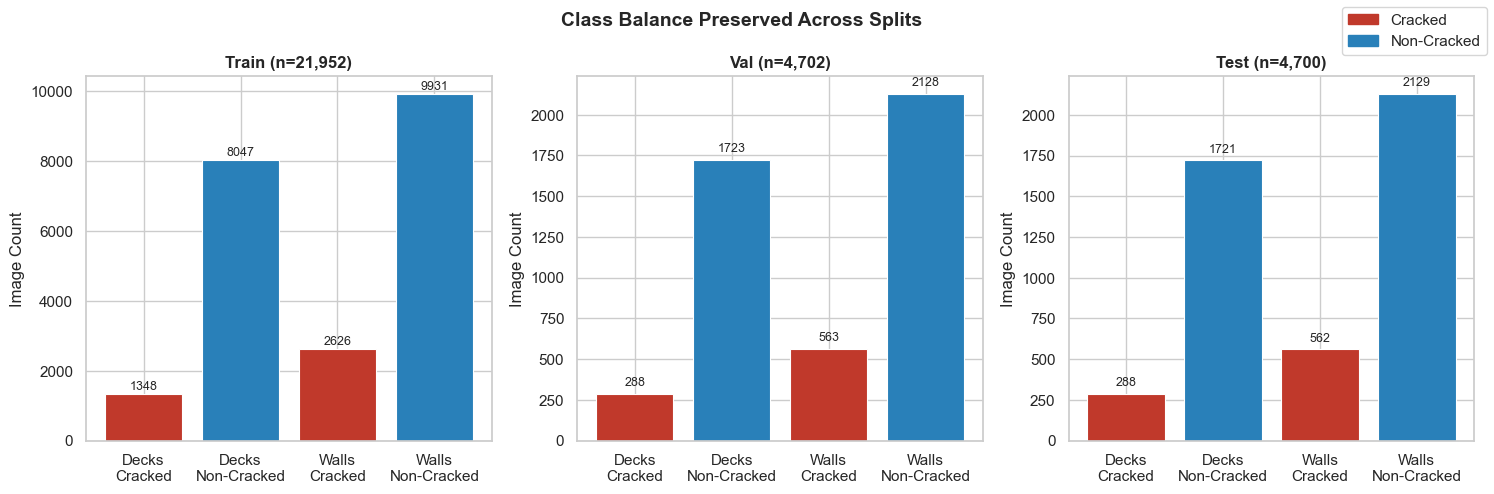

In [20]:
# ── Verify class balance preserved ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"Cracked": "#c0392b", "Non-Cracked": "#2980b9"}

for ax, split_name in zip(axes, ["train", "val", "test"]):
    grp = (df_split[df_split["split"] == split_name]
           .groupby(["domain", "label"]).size().reset_index(name="count"))
    bars = ax.bar([f"{r.domain}\n{r.label}" for _, r in grp.iterrows()],
                  grp["count"], color=[colors[l] for l in grp["label"]],
                  edgecolor="white", linewidth=0.8)
    ax.set_title(f"{split_name.capitalize()} (n={df_split[df_split['split']==split_name].shape[0]:,})",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Image Count")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
fig.legend(handles=patches, loc="upper right", fontsize=11)
plt.suptitle("Class Balance Preserved Across Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [21]:
# ── Save all manifests ────────────────────────────────────────────────────────
MANIFEST_DIR = os.path.join(BASE_PATH, "manifests")
os.makedirs(MANIFEST_DIR, exist_ok=True)

# Main split manifests
df_split.to_csv(os.path.join(MANIFEST_DIR, "full_split_manifest.csv"), index=False)
for split_name in ["train", "val", "test"]:
    df_split[df_split["split"] == split_name].to_csv(
        os.path.join(MANIFEST_DIR, f"{split_name}_manifest.csv"), index=False)

# Flagged images manifest — for Phase 2 recall tracking
df_flagged = df_combined[df_combined["flag"] != "no flag"].copy()
df_flagged["filepath"] = [
    os.path.join(DATA_DIRS[r.Domain], r.Class, fname)
    for (_, r), fname in zip(
        df_flagged.iterrows(),
        [os.listdir(os.path.join(DATA_DIRS[r.Domain], r.Class))[i]
         for i, (_, r) in enumerate(df_flagged.iterrows())]
    )
] if False else None  # filepath joining handled below

# Simpler: merge flags into split manifest by position
df_combined_indexed = df_combined.reset_index(drop=True)
flag_lookup = {}
idx = 0
for domain, root in DATA_DIRS.items():
    for cls in CLASSES:
        folder = os.path.join(root, cls)
        for fname in list_images(folder):
            fpath = os.path.join(folder, fname)
            flag_lookup[fpath] = df_combined_indexed.loc[idx, "flag"]
            idx += 1

df_split["flag"] = df_split["filepath"].map(flag_lookup)
df_split[df_split["flag"] != "no flag"].to_csv(
    os.path.join(MANIFEST_DIR, "flagged_images_manifest.csv"), index=False)

print(f"✅ Manifests saved to: {MANIFEST_DIR}")
print(f"   full_split_manifest.csv       — {len(df_split):,} images")
print(f"   train/val/test_manifest.csv   — split subsets")
print(f"   flagged_images_manifest.csv   — {(df_split['flag'] != 'no flag').sum():,} flagged images")
print(f"   seed: {RANDOM_SEED}  ← fix for all Phase 2 runs")


✅ Manifests saved to: C:\Users\ikerd\Desktop\Vision  Project\Crack-Identification---Group-A\manifests
   full_split_manifest.csv       — 31,354 images
   train/val/test_manifest.csv   — split subsets
   flagged_images_manifest.csv   — 1,754 flagged images
   seed: 42  ← fix for all Phase 2 runs


**Split confirmed:** Stratification preserves the Cracked class percentage (~20.9% Walls, ~14.3% Decks) in every split. Duplicate leakage resolved. All manifests saved — Phase 2 must load these files directly.

## 10. Mystery Test Set Audit

The Mystery Set contains anonymised images from a mixture of asset types, potentially including domains not seen during training. We characterise it statistically and compare against both training pools to anticipate domain shift in Phase 3.

> We do not inspect individual images or attempt to infer labels.

In [22]:
# ── Count and resolution check ────────────────────────────────────────────────
mystery_files = list_images(MYSTERY_DIR)
print(f"Mystery Test Set: {len(mystery_files):,} images")

resolutions = set()
for fname in mystery_files[:50]:
    with Image.open(os.path.join(MYSTERY_DIR, fname)) as img:
        resolutions.add(img.size)
print(f"Resolutions (sample 50): {resolutions}")


Mystery Test Set: 700 images
Resolutions (sample 50): {(256, 256)}


Computing Mystery Set luminance...


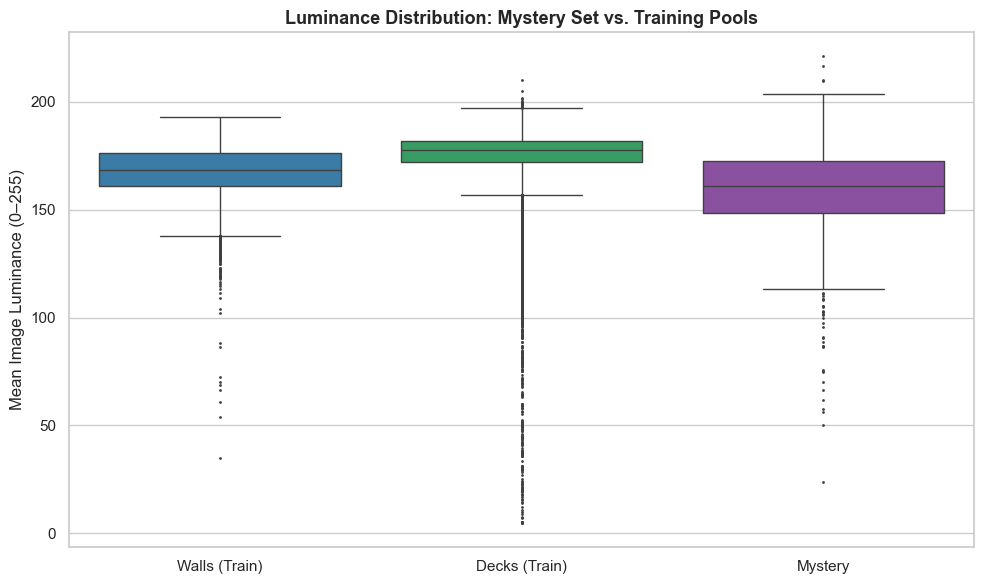

count    700.00
mean     157.70
std       22.68
min       23.70
25%      148.55
50%      161.19
75%      172.45
max      221.42
Name: Luminance, dtype: float64


In [24]:
# ── Luminance distribution vs training pools ──────────────────────────────────
print("Computing Mystery Set luminance...")
mystery_lum = []
for fname in mystery_files:
    img = cv2.imread(os.path.join(MYSTERY_DIR, fname), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        mystery_lum.append(np.mean(img))

df_mystery = pd.DataFrame({"Luminance": mystery_lum, "Source": "Mystery"})
df_compare = pd.concat([
    df_stats[["Luminance"]].assign(Source=df_stats["Domain"] + " (Train)"),
    df_mystery
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_compare, x="Source", y="Luminance",
            order=["Walls (Train)", "Decks (Train)", "Mystery"],
            palette={"Walls (Train)": "#2980b9", "Decks (Train)": "#27ae60", "Mystery": "#8e44ad"},
            flierprops={"marker": ".", "markersize": 2}, ax=ax)
ax.set_title("Luminance Distribution: Mystery Set vs. Training Pools",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Mean Image Luminance (0–255)")
plt.tight_layout()
plt.show()

print(df_mystery["Luminance"].describe().round(2))


Computing Mystery Set edge density...


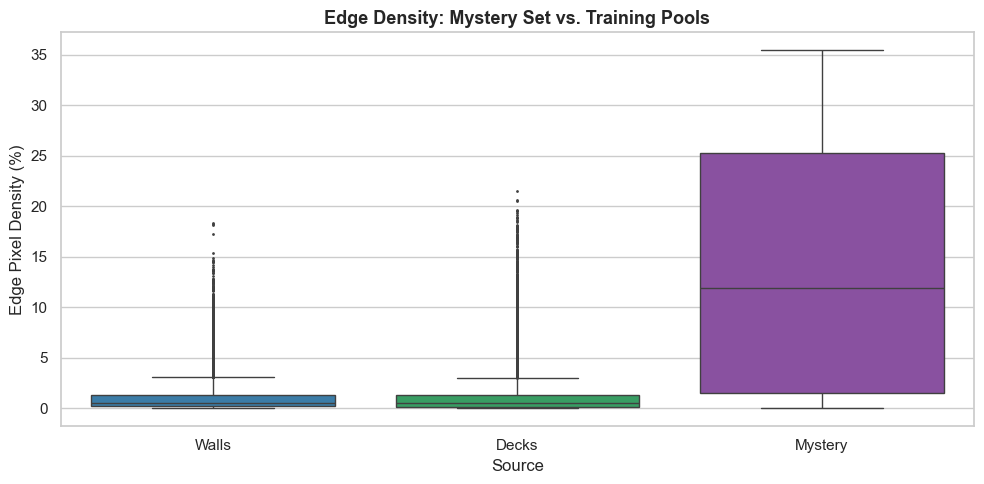

In [25]:
# ── Edge density vs training pools ────────────────────────────────────────────
print("Computing Mystery Set edge density...")
mystery_edge = []
for fname in mystery_files:
    img = cv2.imread(os.path.join(MYSTERY_DIR, fname), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        edges = cv2.Canny(img, 100, 200)
        mystery_edge.append(np.sum(edges > 0) / edges.size * 100)

df_edge_compare = pd.concat([
    df_edges[["Domain", "Edge_Density"]].rename(columns={"Domain": "Source"}),
    pd.DataFrame({"Source": "Mystery", "Edge_Density": mystery_edge})
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_edge_compare, x="Source", y="Edge_Density",
            order=["Walls", "Decks", "Mystery"],
            palette={"Walls": "#2980b9", "Decks": "#27ae60", "Mystery": "#8e44ad"},
            flierprops={"marker": ".", "markersize": 2}, ax=ax)
ax.set_title("Edge Density: Mystery Set vs. Training Pools", fontsize=13, fontweight="bold")
ax.set_ylabel("Edge Pixel Density (%)")
plt.tight_layout()
plt.show()


### 10.3 Mystery Set — Domain-Shift Analysis

**Resolution:** Confirmed 256×256 px across all 700 images — consistent with both training pools.

**Luminance:** The Mystery Set median luminance (~161) sits below both Walls (~167) and Decks (~178), with a wider IQR (148–172) and a lower minimum (23.7). The distribution is closer to Walls than Decks but is more spread out than either, suggesting the set contains images from varied lighting conditions. This is consistent with a third asset type (pavement slabs) captured under more variable outdoor conditions.

**Edge Density:** This is the most significant finding. The Mystery Set has a median edge density of ~12% and an IQR spanning roughly 5–25% — both far exceeding Walls (~1%) and Decks (~1%). This is strong evidence that the Mystery Set contains a structurally different surface type. Pavement slabs have dense aggregate texture, expansion joints, and tyre mark patterns that produce a far higher density of edge-like features than either walls or decks. This means:

1. The CNN will encounter a texture distribution it has never seen during training.
2. The model's learned association between "high edge density = crack" — already a weak signal in training data — is likely to produce a high false-positive rate on Mystery Set images where high edge density is the norm even for non-cracked surfaces.
3. Recall on genuinely cracked Mystery images may also degrade if crack edges are masked by background texture noise.

**Domain-shift risk: High.** The Mystery Set is photometrically and texturally outside the training distribution on the most discriminative feature (edge density). Phase 3 predictions should be interpreted with this caveat, and the Phase 3 report should discuss this explicitly as a limitation of a single generic model trained only on Walls and Decks.